In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, log_loss, brier_score_loss



In [63]:
df = pd.read_csv('dados_processados.csv')

In [64]:
df.tail()

,Date,Season,Home,Away,HG,AG,Res,PSCH,PSCD,PSCA,...,home_ewma_5_goals,away_ewma_5_goals,Res_num,home_last5_winrate,away_last5_winrate,home_points,away_points,home_last5_ppg,away_last5_ppg,entropy
5270,07/12/2025,2025,Ceara,Palmeiras,1.0,3.0,A,1.99,3.31,3.98,...,0.967535,1.910287,0,0.2,0.4,0,3,1.0,1.2,0.958516
5271,07/12/2025,2025,Botafogo RJ,Fortaleza,4.0,2.0,H,1.70,4.00,4.58,...,1.822255,0.877838,2,0.6,0.4,3,0,2.0,1.2,0.903802
5272,07/12/2025,2025,Atletico-MG,Vasco,5.0,0.0,H,1.51,4.11,6.65,...,0.997715,1.496551,2,0.4,0.4,3,0,1.6,1.4,0.826847
5273,07/12/2025,2025,Corinthians,Juventude,1.0,1.0,D,1.76,3.39,5.12,...,1.510097,0.687060,1,0.4,0.0,1,1,1.6,0.2,0.911943
5274,07/12/2025,2025,Vitoria,Sao Paulo,1.0,0.0,H,2.47,3.08,3.10,...,1.202342,0.592185,2,0.6,0.2,3,0,1.8,0.6,0.994696


In [65]:
df.columns

Index(['Date', 'Season', 'Home', 'Away', 'HG', 'AG', 'Res', 'PSCH', 'PSCD',
       'PSCA', 'Date_parsed', 'p_home', 'p_draw', 'p_away', 'dif_prob',
       'dif_draw', 'goal_diff', 'goal_total', 'bucket_favoritismo',
       'home_last5_goals', 'away_last5_goals', 'home_last5_concede',
       'away_last5_concede', 'home_ewma_5_goals', 'away_ewma_5_goals',
       'Res_num', 'home_last5_winrate', 'away_last5_winrate', 'home_points',
       'away_points', 'home_last5_ppg', 'away_last5_ppg', 'entropy'],
      dtype='str')

# selecionando o meu alvo

In [66]:
# Res: 'H' (casa vence), 'D' (empate), 'A' (fora vence)

df['target'] = df['Res'].map({'H':0, 'D': 1, 'A' : 2}) # transformando features categoricas em numericas
df['target_bin'] = (df['Res'] == 'H').astype(int) # target alternativa binaria

In [67]:
eps = 1e-6

In [68]:
# criando novas features para agregar prever o alvo
df['home_goal_ratio'] = df['home_last5_goals'] / (df['home_last5_concede'] + eps)
df['away_goal_ratio'] = df['away_last5_goals'] / (df['away_last5_concede'] + eps)

In [69]:
df['diff_goals']       = df['home_last5_goals'] - df['away_last5_goals']
df['diff_winrate']     = df['home_last5_winrate'] - df['away_last5_winrate']
df['diff_ppg']         = df['home_last5_ppg'] - df['away_last5_ppg']

In [70]:
df['diff_goal_ratio_raw']   = df['home_goal_ratio'] - df['away_goal_ratio']
df['ratio_concede_raw']     = df['away_last5_concede'] / (df['home_last5_concede'] + eps)

In [71]:
df['diferenca_ajustada'] = df['diff_goals'] * df['entropy']

In [72]:
df['dif_draw'] = (df['p_home'] - df['p_draw']) /df['entropy']

In [73]:
# Capping percentis 1/99
for col in ['diff_goal_ratio_raw', 'ratio_concede_raw']:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col.replace('_raw', '_capped')] = df[col].clip(lo, hi)

In [74]:
# Log-transform para diff_goal_ratio
df['log_diff_goal_ratio'] = np.log1p(
    df['diff_goal_ratio_capped'] - df['diff_goal_ratio_capped'].min() + 0.01
)

In [75]:
df['entropy_squared'] = df['entropy'] ** 2

In [76]:
form_prob = df["diff_winrate"] * 0.5 + 0.5

# Quem está mais otimista em relação ao mandante forma ou mercado
df["market_form_direction"] = (
    df["p_home"] - form_prob
)

# Quanto mercado e forma discordam
df["market_form_divergence"] = np.abs(
    df["p_home"] - form_prob
)

In [77]:
df.columns

Index(['Date', 'Season', 'Home', 'Away', 'HG', 'AG', 'Res', 'PSCH', 'PSCD',
       'PSCA', 'Date_parsed', 'p_home', 'p_draw', 'p_away', 'dif_prob',
       'dif_draw', 'goal_diff', 'goal_total', 'bucket_favoritismo',
       'home_last5_goals', 'away_last5_goals', 'home_last5_concede',
       'away_last5_concede', 'home_ewma_5_goals', 'away_ewma_5_goals',
       'Res_num', 'home_last5_winrate', 'away_last5_winrate', 'home_points',
       'away_points', 'home_last5_ppg', 'away_last5_ppg', 'entropy', 'target',
       'target_bin', 'home_goal_ratio', 'away_goal_ratio', 'diff_goals',
       'diff_winrate', 'diff_ppg', 'diff_goal_ratio_raw', 'ratio_concede_raw',
       'diferenca_ajustada', 'diff_goal_ratio_capped', 'ratio_concede_capped',
       'log_diff_goal_ratio', 'entropy_squared', 'market_form_direction',
       'market_form_divergence'],
      dtype='str')

In [78]:
FEATURES_FINAIS = [
    # Mercado (2)
    'dif_prob',
    #'entropy',
    #'PSCH',
    #'PSCD',
    #'PSCA',
    #'dif_draw',

    # Forma relativa — diferenças (2)
    #'diff_goals',
    'diff_winrate',

    # Eficiência ofensiva (2)
    #'home_goal_ratio', 'away_goal_ratio',

    # Vulnerabilidade relativa estabilizada (1)
    'ratio_concede_capped',

    # Interação mercado-forma (1) — NOVA
    'market_form_divergence',

    # Eficiência relativa em log (1) — NOVA
    #'log_diff_goal_ratio',

    # Direção do mercado
    #'market_form_direction',

    # gol,
    #'home_ewma_5_goals', 'away_ewma_5_goals',
    'diferenca_ajustada', 'entropy_squared'



]

In [79]:
df_test = df[FEATURES_FINAIS + ['target_bin']]

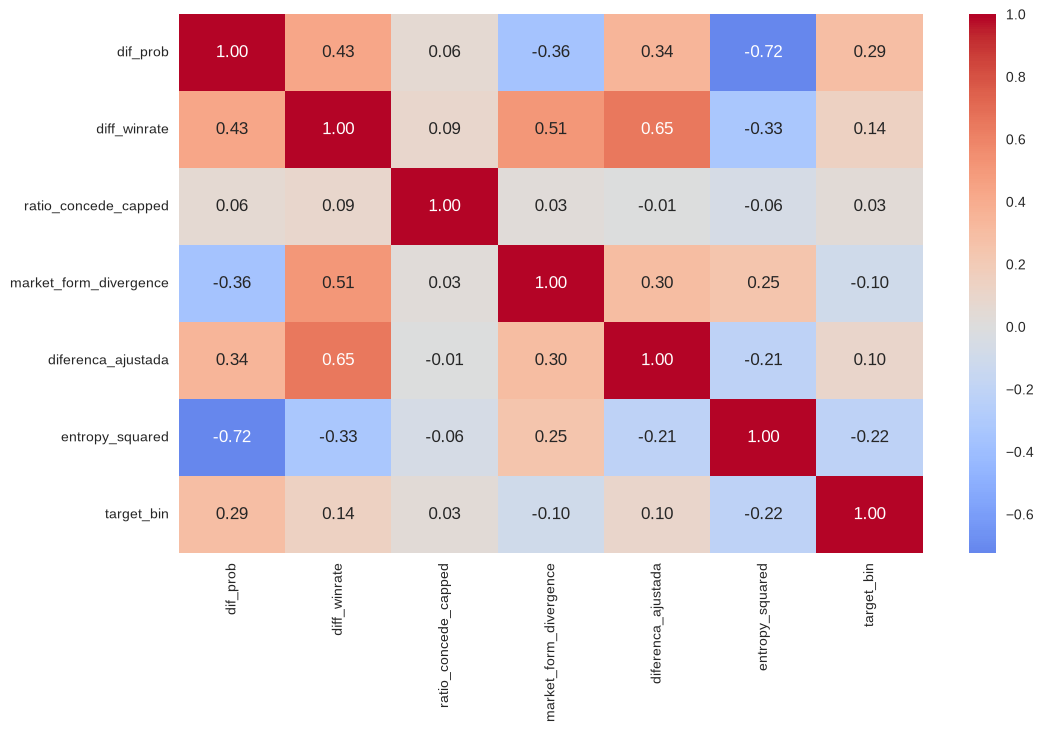

In [80]:
plt.figure(figsize=(12,7))
sns.heatmap(df_test.corr(), annot= True, cmap= 'coolwarm', center = 0, fmt='.2f' )
plt.show()

In [81]:

df_num = df_test.select_dtypes(include=[np.number])
df_num = df_num.dropna()
df_num.shape

(5222, 7)

In [82]:
X = add_constant(df_num)

# calcular VIF para cada coluna (exceto a constante)



vif_data = pd.DataFrame()
vif_data['Variavel']= X.columns[1:] # ignora a constante
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                    for i in range(1, X.shape[1])] # i = 0 é a constante

print(vif_data)


                 Variavel       VIF
0                dif_prob  4.000470
1            diff_winrate  3.977153
2    ratio_concede_capped  1.017282
3  market_form_divergence  3.113018
4      diferenca_ajustada  1.780715
5         entropy_squared  2.120617
6              target_bin  1.090154


In [83]:
EXTRA_COLS = ['Season', 'Home', 'Away','p_home','p_draw', 'p_away', 'PSCH', 'PSCD', 'PSCA', 'Res']

In [84]:
df_model = df[FEATURES_FINAIS + ['target_bin', 'Date_parsed'] + EXTRA_COLS].dropna()
df_model = df_model.sort_values('Date_parsed').reset_index(drop=True)

In [85]:
n = len(df_model)
cut = int( n * 0.8)

X_train = df_model.iloc[:cut][FEATURES_FINAIS]
X_test = df_model.iloc[cut:][FEATURES_FINAIS]
y_train = df_model.iloc[:cut]['target_bin']
y_test = df_model.iloc[cut:]['target_bin']




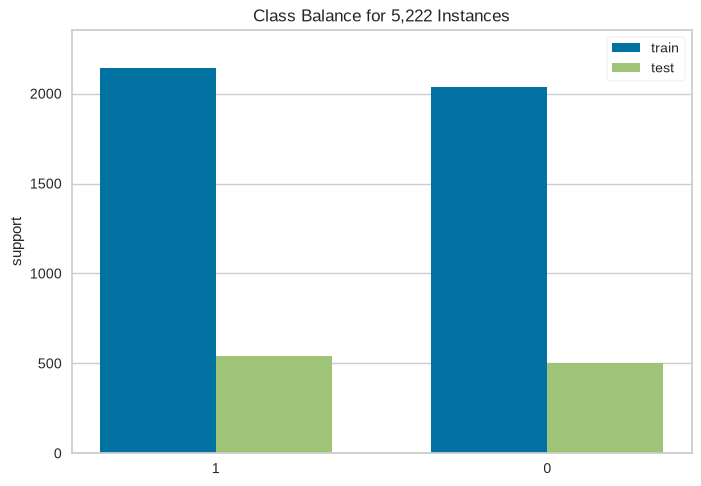

,ax,<Axes: title=...bel='support'>
,labels,"[1, 0]"
,colors,None
,colormap,None
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
support_,"ndarray[int64](2, 2)","[[2141,2036], [ 543, 502]]"


<Figure size 800x550 with 0 Axes>

In [86]:
from yellowbrick.target import class_balance

class_balance(y_train, y_test, labels=[1,0])




In [87]:
print(len(X_train))

print(len(X_test))

4177
1045


In [88]:
X_train.isna().sum()

dif_prob                  0
diff_winrate              0
ratio_concede_capped      0
market_form_divergence    0
diferenca_ajustada        0
entropy_squared           0
dtype: int64

In [89]:
X_test.isna().sum()

dif_prob                  0
diff_winrate              0
ratio_concede_capped      0
market_form_divergence    0
diferenca_ajustada        0
entropy_squared           0
dtype: int64

In [90]:
# periodo de treino
print(df_model.iloc[0]['Date_parsed'])
print(df_model.iloc[cut-1]['Date_parsed'])


2012-06-06
2023-05-11


In [91]:
# tratar Nan/inf
# X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
# X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)



# MODELO BASE

In [92]:
from sklearn.dummy import DummyClassifier

In [93]:
bm = DummyClassifier()

In [94]:
bm.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.51,0.49]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](6,)","['dif_prob','diff_winrate','ratio_concede_capped','market_form_divergence', 'diferenca_ajustada','entropy_squared']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,6
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [95]:
#bm.score(X_test, y_test)

# treinar modelo de regre. logistica

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

In [97]:
scaler = StandardScaler() # padronizar as variáveis ( média - 0, desvio = 1)

X_train_scaled = scaler.fit_transform(X_train) # ajsuta nos dados de treino
X_test_scaled = scaler.fit_transform(X_test) # aplica a mesma tranformação no teste sem vazamento

model = LogisticRegression(random_state=42, solver = 'liblinear', class_weight='balanced', max_iter= 1000)
model.fit(X_train_scaled, y_train)

print('\n Modelo Treinado com sucesso !')


 Modelo Treinado com sucesso !


In [98]:
y_pred = model.predict(X_test_scaled) # fzer previsão

y_proba = model.predict_proba(X_test_scaled)[:,1] # Probabilidade da classe 1


In [99]:
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.4f}")
print(classification_report(y_test, y_pred))
auc = roc_auc_score(y_test, y_proba)
print(f'AUC-ROC: {auc:.4f}')
print(f'Brier: {brier_score_loss(y_test, y_proba):.4f}')
print(f"LogLoss:  {log_loss(y_test, y_proba):.4f}")

Acurácia: 0.6153
              precision    recall  f1-score   support

           0       0.64      0.59      0.61       543
           1       0.59      0.64      0.62       502

    accuracy                           0.62      1045
   macro avg       0.62      0.62      0.62      1045
weighted avg       0.62      0.62      0.62      1045

AUC-ROC: 0.6704
Brier: 0.2284
LogLoss:  0.6482


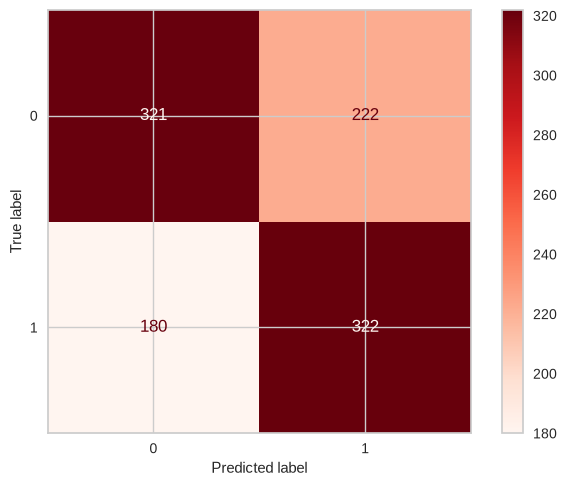

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.show()

In [101]:
# from yellowbrick.classifier import ROCAUC


# visualizer = ROCAUC(model, classes= [0,1])

# visualizer.fit(X_train_scaled, y_train)
# visualizer.score(X_test_scaled, y_test)

# visualizer.show()



In [102]:
df_test = df_model.iloc[cut:].copy()

df_test['prob_modelo'] = y_proba
df_test['prob_modelo'].describe()

count    1045.000000
mean        0.499172
std         0.142071
min         0.104499
25%         0.399447
50%         0.507477
75%         0.613206
max         0.822593
Name: prob_modelo, dtype: float64

In [103]:
df_test.columns

Index(['dif_prob', 'diff_winrate', 'ratio_concede_capped',
       'market_form_divergence', 'diferenca_ajustada', 'entropy_squared',
       'target_bin', 'Date_parsed', 'Season', 'Home', 'Away', 'p_home',
       'p_draw', 'p_away', 'PSCH', 'PSCD', 'PSCA', 'Res', 'prob_modelo'],
      dtype='str')

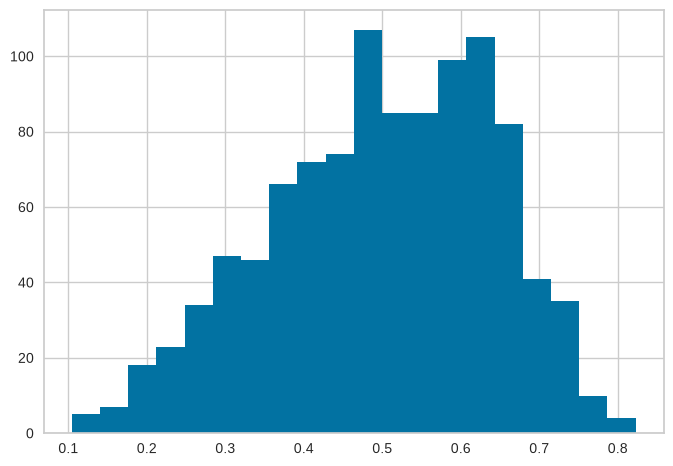

In [104]:
plt.hist(df_test['prob_modelo'], bins = 20)
plt.show()

In [105]:
df_test['prob_mercado'] = df_test['p_home']
df_test[['prob_modelo', 'prob_mercado']].describe()

,prob_modelo,prob_mercado
count,1045.000000,1045.000000
mean,0.499172,0.464022
std,0.142071,0.132549
min,0.104499,0.105966
25%,0.399447,0.368426
50%,0.507477,0.465479
75%,0.613206,0.560000
max,0.822593,0.811883


In [106]:
df_test[["prob_modelo","prob_mercado"]].corr()

,prob_modelo,prob_mercado
prob_modelo,1.000000,0.987609
prob_mercado,0.987609,1.000000


In [107]:
df_test["edge_modelo"] = (
    df_test["prob_modelo"] -
    df_test["prob_mercado"]
)

df_test["edge_modelo"].describe()

count    1045.000000
mean        0.035150
std         0.023608
min        -0.104114
25%         0.020647
50%         0.040620
75%         0.052103
max         0.109434
Name: edge_modelo, dtype: float64

In [149]:
df_test.sort_values(
    "edge_modelo",
    ascending=True
)[[
    "Home",
    "Away",
    "PSCH",
    "prob_modelo",
    "prob_mercado",
    "Res"
]].head(5)

,Home,Away,PSCH,prob_modelo,prob_mercado,Res
5151,Palmeiras,Bragantino,5.28,0.038384,0.180168,H
4803,Juventude,Palmeiras,5.37,0.038384,0.179988,A
5144,Bahia,Flamengo RJ,5.93,0.038384,0.162960,H
5206,Juventude,Santos,5.52,0.052850,0.175181,A
5049,Ceara,Flamengo RJ,5.79,0.046409,0.166357,D


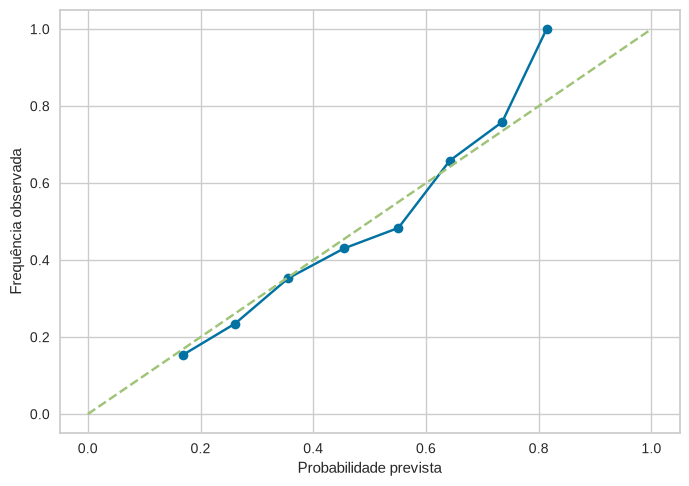

In [109]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba,
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.show()

<Figure size 600x600 with 0 Axes>

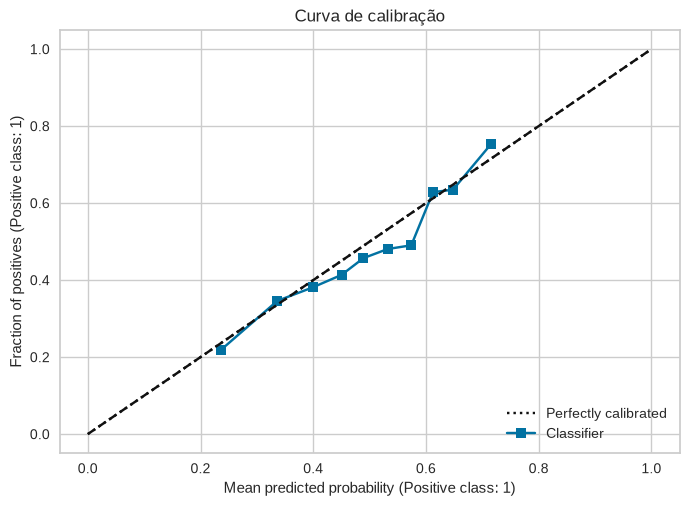

In [140]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

CalibrationDisplay.from_predictions(
    y_test,
    y_proba,          # ou y_proba_calib para o modelo calibrado
    n_bins=10,
    strategy="quantile"
)

plt.plot([0,1],[0,1],"k--")
plt.title("Curva de calibração")
plt.show()

In [110]:
df_test["lucro_home"] = np.where(
    df_test["target_bin"] == 1,
    df_test["PSCH"] - 1,   # ganhou a aposta
    -1                     # perdeu a stake
)

In [111]:
df_test["EV"] = df_test["prob_modelo"] * df_test["PSCH"] - 1

for limite in [0.00, 0.05, 0.10, 0.15]:
    apostas = df_test[df_test["EV"] > limite]

    roi = apostas["lucro_home"].mean()

    print(
        f"EV>{limite:.2f} | "
        f"Apostas={len(apostas):4d} | "
        f"ROI={roi:.3f} | "
        f"Acerto={apostas['target_bin'].mean():.3f} | "
        f"Odd média={apostas['PSCH'].mean():.2f} | "
        f"EV médio={apostas['EV'].mean():.3f}"
    )

EV>0.00 | Apostas= 859 | ROI=-0.002 | Acerto=0.488 | Odd média=2.18 | EV médio=0.056
EV>0.05 | Apostas= 519 | ROI=0.003 | Acerto=0.489 | Odd média=2.12 | EV médio=0.074
EV>0.10 | Apostas=  39 | ROI=-0.275 | Acerto=0.333 | Odd média=2.22 | EV médio=0.116
EV>0.15 | Apostas=   3 | ROI=0.370 | Acerto=0.667 | Odd média=1.99 | EV médio=0.170


In [112]:

# ---------- Função para avaliar um filtro qualquer ----------
def avaliar_filtro(df, filtro_nome, condicao):
    """
    Aplica uma condição booleana ao DataFrame e imprime as métricas.
    condicao: uma expressão booleana (ex: df['EV'] > 0.04)
              ou uma função que retorna uma série booleana.
    """
    if callable(condicao):
        mask = condicao(df)
    else:
        mask = condicao
    apostas = df[mask]
    if len(apostas) == 0:
        print(f"{filtro_nome}: Nenhuma aposta encontrada.")
        return
    roi = apostas["lucro_home"].mean()
    acerto = apostas["target_bin"].mean()
    odd_media = apostas["PSCH"].mean()
    ev_medio = apostas["EV"].mean()
    print(f"{filtro_nome:30s} | "
          f"Apostas={len(apostas):4d} | "
          f"ROI={roi:6.3f} | "
          f"Acerto={acerto:6.3f} | "
          f"Odd média={odd_media:6.2f} | "
          f"EV médio={ev_medio:6.3f}")

# ---------- 1. Filtro sugerido: EV entre 0.04 e 0.10 ----------
avaliar_filtro(
    df_test,
    "EV 0.04 ~ 0.10 (puro)",
    (df_test["EV"] > 0.04) & (df_test["EV"] < 0.10)
)

# ---------- 2. EV entre 0.04 e 0.10 + Probabilidade >= 0.35 ----------
avaliar_filtro(
    df_test,
    "EV 0.04~0.10 + prob>=0.35",
    (df_test["EV"] > 0.04) & (df_test["EV"] < 0.10) & (df_test["prob_modelo"] >= 0.35)
)

# ---------- 3. EV entre 0.04 e 0.10 + Odd máxima 3.80 ----------
avaliar_filtro(
    df_test,
    "EV 0.04~0.10 + odd<=3.80",
    (df_test["EV"] > 0.04) & (df_test["EV"] < 0.10) & (df_test["PSCH"] <= 3.80)
)

# ---------- 4. Combinação: EV 0.03~0.09 (mais volume) ----------
avaliar_filtro(
    df_test,
    "EV 0.03 ~ 0.09 + prob>=0.33",
    (df_test["EV"] > 0.03) & (df_test["EV"] < 0.09) & (df_test["prob_modelo"] >= 0.33)
)

# ---------- 5. Teste do melhor bucket calibrado (EV >0.05) com odds limitada ----------
avaliar_filtro(
    df_test,
    "EV>0.05 + odd<=3.80",
    (df_test["EV"] > 0.05) & (df_test["PSCH"] <= 3.80)
)

# ---------- 6. Filtro ainda mais restrito (EV 0.04~0.08 + prob>=0.38 + odd<=3.50) ----------
avaliar_filtro(
    df_test,
    "EV 0.04~0.08 + prob>=0.38 + odd<=3.50",
    (df_test["EV"] > 0.04) & (df_test["EV"] < 0.08) &
    (df_test["prob_modelo"] >= 0.38) & (df_test["PSCH"] <= 3.50)
)

EV 0.04 ~ 0.10 (puro)          | Apostas= 590 | ROI= 0.031 | Acerto= 0.510 | Odd média=  2.10 | EV médio= 0.065
EV 0.04~0.10 + prob>=0.35      | Apostas= 573 | ROI= 0.020 | Acerto= 0.513 | Odd média=  2.06 | EV médio= 0.066
EV 0.04~0.10 + odd<=3.80       | Apostas= 588 | ROI= 0.027 | Acerto= 0.510 | Odd média=  2.10 | EV médio= 0.065
EV 0.03 ~ 0.09 + prob>=0.33    | Apostas= 597 | ROI= 0.039 | Acerto= 0.524 | Odd média=  2.06 | EV médio= 0.061
EV>0.05 + odd<=3.80            | Apostas= 516 | ROI= 0.002 | Acerto= 0.490 | Odd média=  2.11 | EV médio= 0.073
EV 0.04~0.08 + prob>=0.38 + odd<=3.50 | Apostas= 442 | ROI= 0.051 | Acerto= 0.543 | Odd média=  1.99 | EV médio= 0.060


In [126]:
df_teste_temporal = df_test.sort_values('Date_parsed').tail(int(len(df)*0.2))

filtro_f6 = (
    (df_teste_temporal['EV'] > 0.04) &
    (df_teste_temporal['EV'] < 0.08) &
    (df_teste_temporal['prob_modelo'] >= 0.38) &
    (df_teste_temporal['PSCH'] <= 3.50)
)

apostas_f6_temporal = df_teste_temporal[filtro_f6]

roi_temporal = apostas_f6_temporal['lucro_home'].mean()
print(f"ROI no período recente (validação): {roi_temporal:.3f}")
print(f"Apostas: {len(apostas_f6_temporal)}")

ROI no período recente (validação): 0.052
Apostas: 192


# Calibração de Probabilidades

In [127]:
from sklearn.calibration import CalibratedClassifierCV

# Crie um modelo calibrado (joga os dados de treino, mas ele usa validação cruzada interna)
calibrated_model = CalibratedClassifierCV(LogisticRegression(random_state=42, solver='liblinear'),
                                          method='isotonic', cv=5)
calibrated_model.fit(X_train_scaled, y_train)

# Previsões calibradas
y_proba_calib = calibrated_model.predict_proba(X_test_scaled)[:, 1]

# Recalcule o EV e o ROI com essas novas probabilidades
# (Substitua y_proba por y_proba_calib no loop de EV)

In [128]:
auc = roc_auc_score(y_test, y_proba_calib)
print(f'AUC-ROC: {auc:.4f}')
print(f'Brier: {brier_score_loss(y_test, y_proba_calib):.4f}')
print(f"LogLoss:  {log_loss(y_test, y_proba_calib):.4f}")

AUC-ROC: 0.6708
Brier: 0.2288
LogLoss:  0.6508


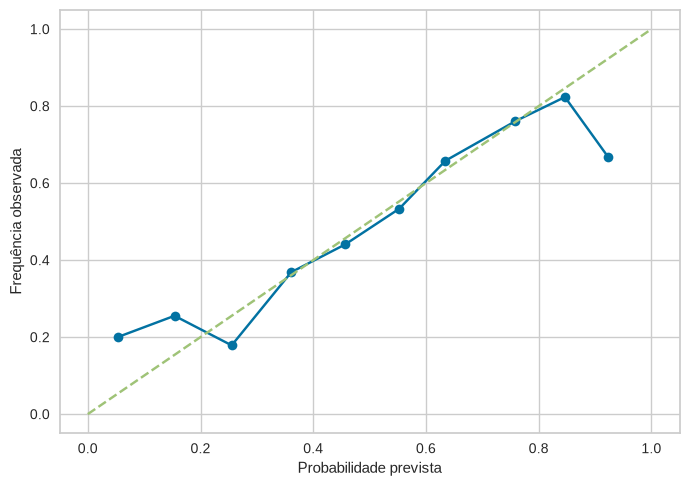

In [129]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba_calib,
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.show()

<Figure size 600x600 with 0 Axes>

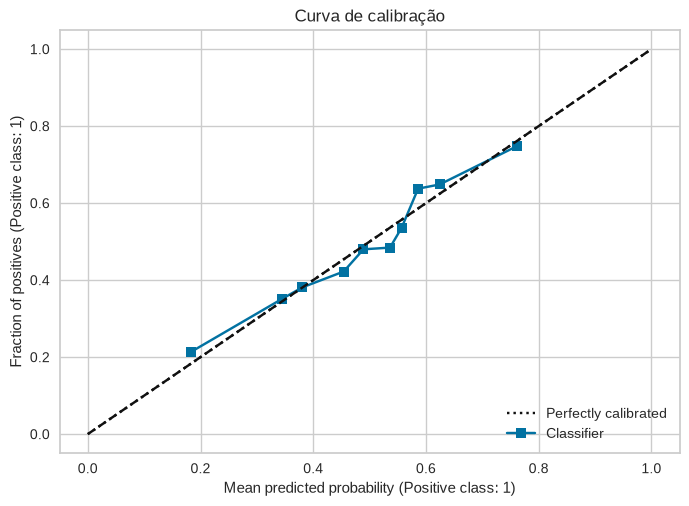

In [139]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

CalibrationDisplay.from_predictions(
    y_test,
    y_proba_calib,          # ou y_proba_calib para o modelo calibrado
    n_bins=10,
    strategy="quantile"
)

plt.plot([0,1],[0,1],"k--")
plt.title("Curva de calibração")
plt.show()

In [141]:
df_calib = df_model.iloc[cut:].copy()

df_calib['prob_modelo'] = y_proba_calib
df_calib['prob_modelo'].describe()

count    1045.000000
mean        0.485283
std         0.156041
min         0.027273
25%         0.377929
50%         0.515022
75%         0.570093
max         0.940000
Name: prob_modelo, dtype: float64

In [142]:

df_calib['prob_mercado'] = df_test['p_home']
df_calib[['prob_modelo', 'prob_mercado']].describe()


,prob_modelo,prob_mercado
count,1045.000000,1045.000000
mean,0.485283,0.464022
std,0.156041,0.132549
min,0.027273,0.105966
25%,0.377929,0.368426
50%,0.515022,0.465479
75%,0.570093,0.560000
max,0.940000,0.811883


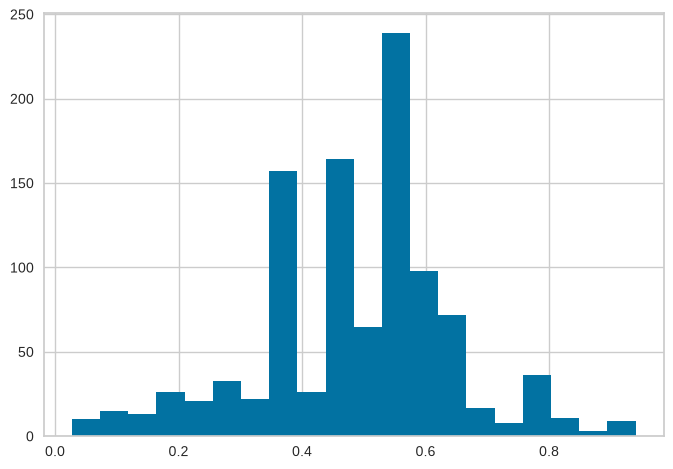

In [143]:
plt.hist(df_calib['prob_modelo'], bins = 20)
plt.show()

In [144]:
df_calib['prob_modelo'] = y_proba_calib
df_calib['prob_modelo'].describe()

count    1045.000000
mean        0.485283
std         0.156041
min         0.027273
25%         0.377929
50%         0.515022
75%         0.570093
max         0.940000
Name: prob_modelo, dtype: float64

In [145]:
df_calib[["prob_modelo","prob_mercado"]].corr()

,prob_modelo,prob_mercado
prob_modelo,1.000000,0.974821
prob_mercado,0.974821,1.000000


In [146]:
df_calib["edge_modelo"] = (
    df_calib["prob_modelo"] -
    df_calib["prob_mercado"]
)


In [148]:
df_calib.sort_values(
    "edge_modelo",
    ascending=True
)[[
    "Home",
    "Away",
    "PSCH",
    "prob_modelo",
    "prob_mercado",
    "Res"
]].head(5)

,Home,Away,PSCH,prob_modelo,prob_mercado,Res
5151,Palmeiras,Bragantino,5.28,0.038384,0.180168,H
4803,Juventude,Palmeiras,5.37,0.038384,0.179988,A
5144,Bahia,Flamengo RJ,5.93,0.038384,0.162960,H
5206,Juventude,Santos,5.52,0.052850,0.175181,A
5049,Ceara,Flamengo RJ,5.79,0.046409,0.166357,D


In [152]:
df_calib["lucro_home"] = np.where(
    df_calib["target_bin"] == 1,
    df_calib["PSCH"] - 1,   # ganhou a aposta
    -1                     # perdeu a stake
)

In [153]:
df_calib["EV"] = df_calib["prob_modelo"] * df_calib["PSCH"] - 1

for limite in [0.00, 0.05, 0.10, 0.15]:
    apostas = df_calib[df_calib["EV"] > limite]

    roi = apostas["lucro_home"].mean()

    print(
        f"EV>{limite:.2f} | "
        f"Apostas={len(apostas):4d} | "
        f"ROI={roi:.3f} | "
        f"Acerto={apostas['target_bin'].mean():.3f} | "
        f"Odd média={apostas['PSCH'].mean():.2f} | "
        f"EV médio={apostas['EV'].mean():.3f}"
    )

EV>0.00 | Apostas= 663 | ROI=0.017 | Acerto=0.498 | Odd média=2.15 | EV médio=0.053
EV>0.05 | Apostas= 333 | ROI=0.011 | Acerto=0.483 | Odd média=2.18 | EV médio=0.084
EV>0.10 | Apostas=  80 | ROI=-0.049 | Acerto=0.500 | Odd média=2.10 | EV médio=0.121
EV>0.15 | Apostas=   5 | ROI=0.500 | Acerto=1.000 | Odd média=1.50 | EV médio=0.180


In [155]:

# ---------- Função para avaliar um filtro qualquer ----------
def avaliar_filtro(df, filtro_nome, condicao):
    """
    Aplica uma condição booleana ao DataFrame e imprime as métricas.
    condicao: uma expressão booleana (ex: df['EV'] > 0.04)
              ou uma função que retorna uma série booleana.
    """
    if callable(condicao):
        mask = condicao(df)
    else:
        mask = condicao
    apostas = df[mask]
    if len(apostas) == 0:
        print(f"{filtro_nome}: Nenhuma aposta encontrada.")
        return
    roi = apostas["lucro_home"].mean()
    acerto = apostas["target_bin"].mean()
    odd_media = apostas["PSCH"].mean()
    ev_medio = apostas["EV"].mean()
    print(f"{filtro_nome:30s} | "
          f"Apostas={len(apostas):4d} | "
          f"ROI={roi:6.3f} | "
          f"Acerto={acerto:6.3f} | "
          f"Odd média={odd_media:6.2f} | "
          f"EV médio={ev_medio:6.3f}")

# ---------- 1. Filtro sugerido: EV entre 0.04 e 0.10 ----------
avaliar_filtro(
    df_calib,
    "EV 0.04 ~ 0.10 (puro)",
    (df_calib["EV"] > 0.04) & (df_calib["EV"] < 0.10)
)

# ---------- 2. EV entre 0.04 e 0.10 + Probabilidade >= 0.35 ----------
avaliar_filtro(
    df_calib,
    "EV 0.04~0.10 + prob>=0.35",
    (df_calib["EV"] > 0.04) & (df_calib["EV"] < 0.10) & (df_calib["prob_modelo"] >= 0.35)
)

# ---------- 3. EV entre 0.04 e 0.10 + Odd máxima 3.80 ----------
avaliar_filtro(
    df_calib,
    "EV 0.04~0.10 + odd<=3.80",
    (df_calib["EV"] > 0.04) & (df_calib["EV"] < 0.10) & (df_calib["PSCH"] <= 3.80)
)

# ---------- 4. Combinação: EV 0.03~0.09 (mais volume) ----------
avaliar_filtro(
    df_calib,
    "EV 0.03 ~ 0.09 + prob>=0.33",
    (df_calib["EV"] > 0.03) & (df_calib["EV"] < 0.09) & (df_calib["prob_modelo"] >= 0.33)
)

# ---------- 5. Teste do melhor bucket calibrado (EV >0.05) com odds limitada ----------
avaliar_filtro(
    df_calib,
    "EV>0.05 + odd<=3.80",
    (df_calib["EV"] > 0.05) & (df_calib["PSCH"] <= 3.80)
)

# ---------- 6. Filtro ainda mais restrito (EV 0.04~0.08 + prob>=0.38 + odd<=3.50) ----------
avaliar_filtro(
    df_calib,
    "EV 0.04~0.08 + prob>=0.38 + odd<=3.50",
    (df_calib["EV"] > 0.04) & (df_calib["EV"] < 0.08) &
    (df_calib["prob_modelo"] >= 0.38) & (df_calib["PSCH"] <= 3.50)
)

EV 0.04 ~ 0.10 (puro)          | Apostas= 299 | ROI= 0.050 | Acerto= 0.492 | Odd média=  2.20 | EV médio= 0.068
EV 0.04~0.10 + prob>=0.35      | Apostas= 274 | ROI= 0.022 | Acerto= 0.496 | Odd média=  2.12 | EV médio= 0.068
EV 0.04~0.10 + odd<=3.80       | Apostas= 299 | ROI= 0.050 | Acerto= 0.492 | Odd média=  2.20 | EV médio= 0.068
EV 0.03 ~ 0.09 + prob>=0.33    | Apostas= 326 | ROI= 0.032 | Acerto= 0.488 | Odd média=  2.20 | EV médio= 0.060
EV>0.05 + odd<=3.80            | Apostas= 333 | ROI= 0.011 | Acerto= 0.483 | Odd média=  2.18 | EV médio= 0.084
EV 0.04~0.08 + prob>=0.38 + odd<=3.50 | Apostas= 192 | ROI= 0.052 | Acerto= 0.516 | Odd média=  2.07 | EV médio= 0.061


In [157]:
df_teste_temporal = df_calib.sort_values('Date_parsed').tail(int(len(df)*0.2))

filtro_f6 = (
    (df_teste_temporal['EV'] > 0.04) &
    (df_teste_temporal['EV'] < 0.08) &
    (df_teste_temporal['prob_modelo'] >= 0.38) &
    (df_teste_temporal['PSCH'] <= 3.50)
)

apostas_f6_temporal = df_teste_temporal[filtro_f6]

roi_temporal = apostas_f6_temporal['lucro_home'].mean()
print(f"ROI no período recente (validação): {roi_temporal:.3f}")
print(f"Apostas: {len(apostas_f6_temporal)}")

ROI no período recente (validação): 0.052
Apostas: 192
